In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1296675, 23)
Test Shape: (555719, 23)


In [7]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [11]:
train_df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [13]:
train_df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [15]:
fraud_percent = train_df['is_fraud'].value_counts(normalize=True) * 100
print(fraud_percent)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [17]:
train_df['trans_date_trans_time'] = pd.to_datetime(
    train_df['trans_date_trans_time']
)

test_df['trans_date_trans_time'] = pd.to_datetime(
    test_df['trans_date_trans_time']
)

train_df['dob'] = pd.to_datetime(train_df['dob'])
test_df['dob'] = pd.to_datetime(test_df['dob'])

In [19]:
train_df['trans_hour'] = train_df['trans_date_trans_time'].dt.hour
test_df['trans_hour'] = test_df['trans_date_trans_time'].dt.hour

# Day of week
train_df['trans_day'] = train_df['trans_date_trans_time'].dt.dayofweek
test_df['trans_day'] = test_df['trans_date_trans_time'].dt.dayofweek

# Month
train_df['trans_month'] = train_df['trans_date_trans_time'].dt.month
test_df['trans_month'] = test_df['trans_date_trans_time'].dt.month

# Customer age
train_df['age'] = (
    train_df['trans_date_trans_time'].dt.year
    - train_df['dob'].dt.year
)

test_df['age'] = (
    test_df['trans_date_trans_time'].dt.year
    - test_df['dob'].dt.year
)

In [21]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


# Train distance
train_df['distance'] = haversine(
    train_df['lat'],
    train_df['long'],
    train_df['merch_lat'],
    train_df['merch_long']
)

# Test distance
test_df['distance'] = haversine(
    test_df['lat'],
    test_df['long'],
    test_df['merch_lat'],
    test_df['merch_long']
)

In [23]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'merchant',
    'first',
    'last',
    'street',
    'city',
    'state',
    'zip',
    'job',
    'dob',
    'trans_num'
]

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [29]:
categorical_cols = train_df.select_dtypes(include='object').columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

    label_encoders[col] = le

In [31]:
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']

X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

print(X_train.shape)
print(X_test.shape)

(1296675, 14)
(555719, 14)


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [39]:
# Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Probability scores
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9712192672915628
ROC AUC Score: 0.8520951798005995

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.09      0.74      0.16      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.85      0.58    555719
weighted avg       1.00      0.97      0.98    555719



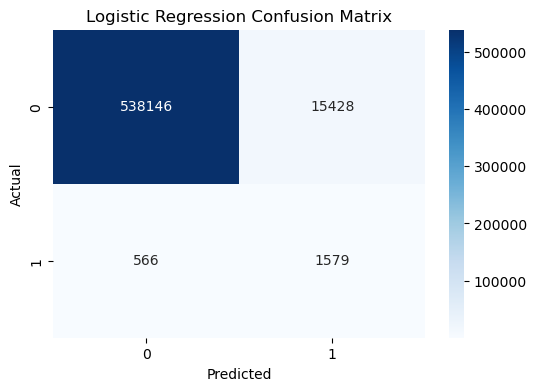

In [41]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [45]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9730907167111436
ROC AUC Score: 0.9815750202437439

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.12      0.96      0.22      2145

    accuracy                           0.97    555719
   macro avg       0.56      0.96      0.60    555719
weighted avg       1.00      0.97      0.98    555719



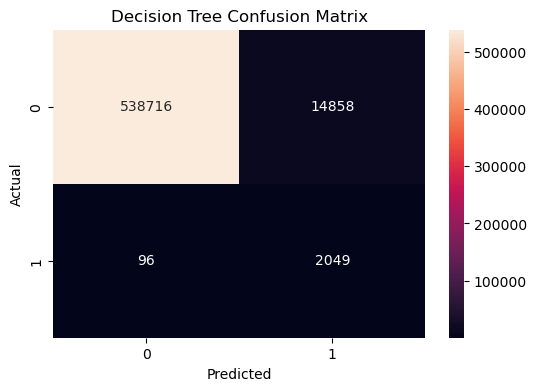

In [47]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [49]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9898041996044764
ROC AUC Score: 0.9903617605092023

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.26      0.88      0.40      2145

    accuracy                           0.99    555719
   macro avg       0.63      0.94      0.70    555719
weighted avg       1.00      0.99      0.99    555719



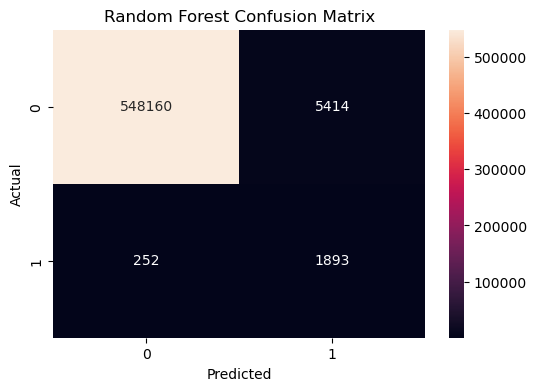

In [51]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [53]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
1           amt    0.622678
9    trans_hour    0.218951
0      category    0.081063
12          age    0.015696
6     unix_time    0.011527
5      city_pop    0.009253
3           lat    0.006380
11  trans_month    0.006370
4          long    0.005831
7     merch_lat    0.005636
8    merch_long    0.005330
2        gender    0.004612
13     distance    0.003783
10    trans_day    0.002891


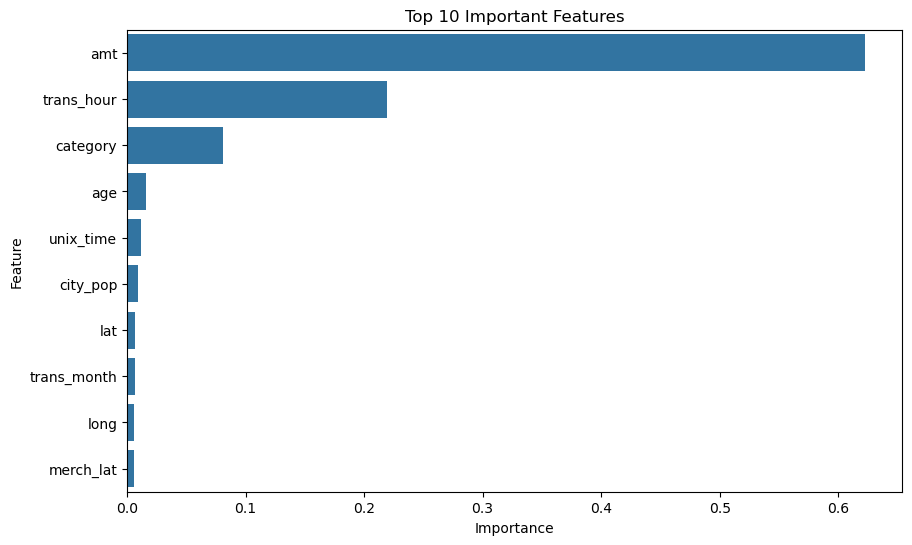

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [57]:
import pickle
pickle.dump(rf_model, open('fraud_detection_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!
